# Inferencia estadística vs Aprendizaje de máquinas

### Parte 1: Ajuste de recta 

(Adaptado de  Viviana Acquaviva (2023))

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
#parámetros para generar figuras de alta calidad
font = {'size'   : 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

Generaremos datos que sigan una relación lineal (con ruido) y usaremos una grilla para encontrar el mejor ajuste, sin y con considerar incertezas

In [3]:
np.random.seed(16) #semilla fija para reproducibilidad

x = np.arange(10) 

y = 2*x + 5 + np.random.randn(10) #generamos datos con scatter gausiano

Podemos considerar que los datos corresponden al movimiento de un auto con rapidez constante, donde $x$ es tiempo (en segundos) e $y$ es distancia (en metros)

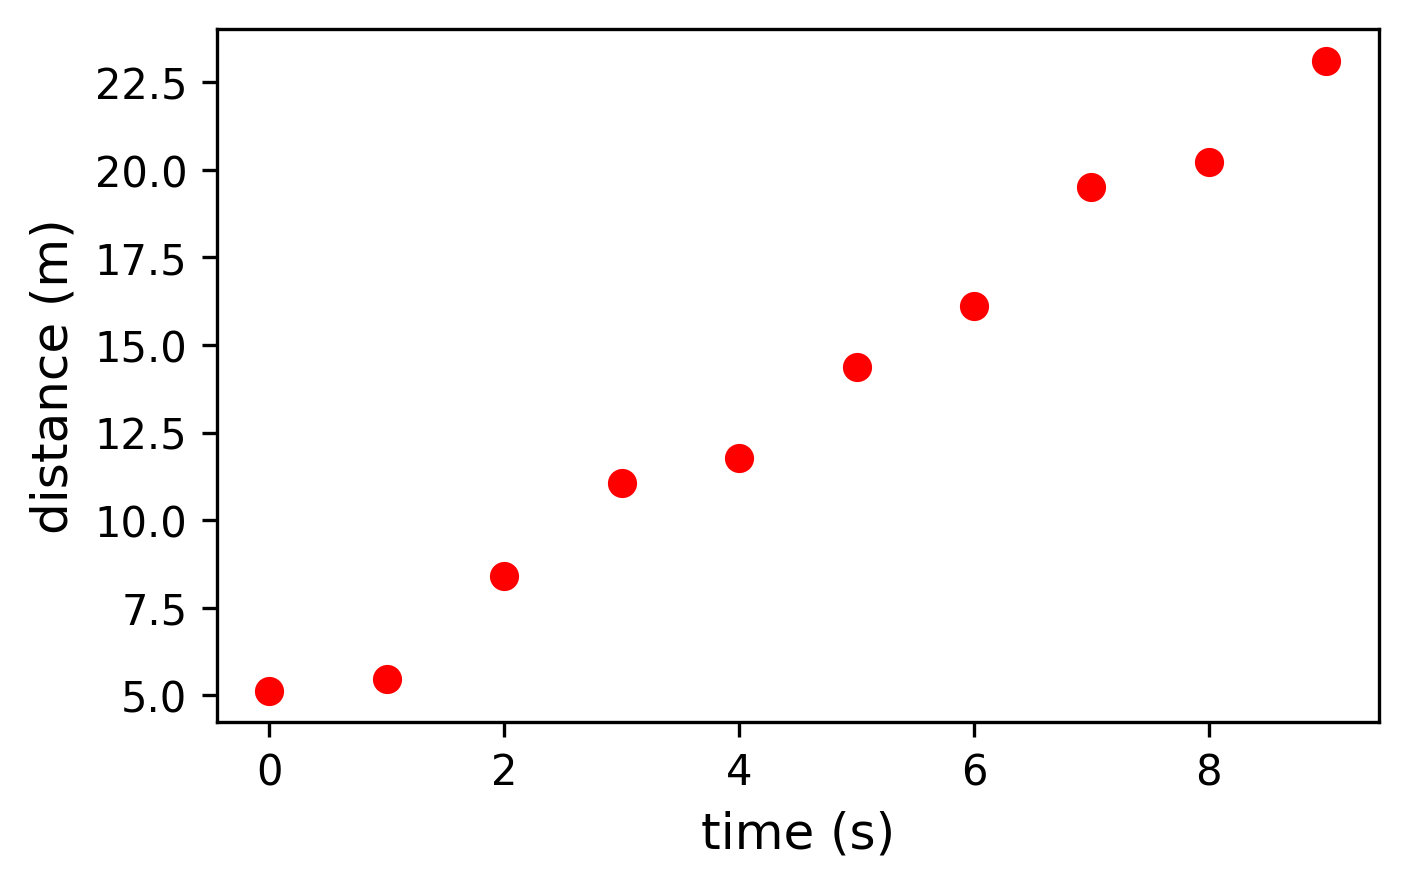

In [4]:
plt.figure(figsize=(5,3)) #
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)');

In [5]:
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [6]:
y = np.round(y,1) #redondeamos los datos

In [7]:
y

array([ 5.1,  5.5,  8.4, 11.1, 11.8, 14.4, 16.1, 19.5, 20.2, 23.1])

Suponga que a partir de esos datos debe ser capaz de decir la distancia a la que estará el auto cuando $t=12$ s. ¿Cómo podemos resolver el problema?

### Inferencia

Ya sabemos que la relación entre distancia y tiempo, para una partícula con rapidez constante está dada por $$d=d_0 +vt$$. Este modelo tienen dos parámetros: $d_0$ u $v$. Necesitamos encontrar estos parámetros para poder usar el modelo y determinar $d(t=12 s)$.


¿Cómo haría esto?




Explique con palabras: 
Usando los minimos cuadrados se puede encontrar la recta más optima que mejor representa el ajuste, de esta forma se encuentra una ecuación de la recta que se puede usar para encontrar el valor de $d(t=12 s)$

<details>
<summary>Ayuda!</summary>
Podemos considerar el error en un ajuste de recta como la suma de errores, que consideramos la suma al cuadrado de las distancia entre las distancias predichas por el el modelo ($D^m_i$) y las observadas ($D^o_i$) $$\sum_{i=1}^{10}(D^m(d_0,v,x_i)-D^o_i)^2$$

Encuentre los parámetros de la mejor recta para los datos dados

Ecuación óptima: d = 2.048t + 4.302


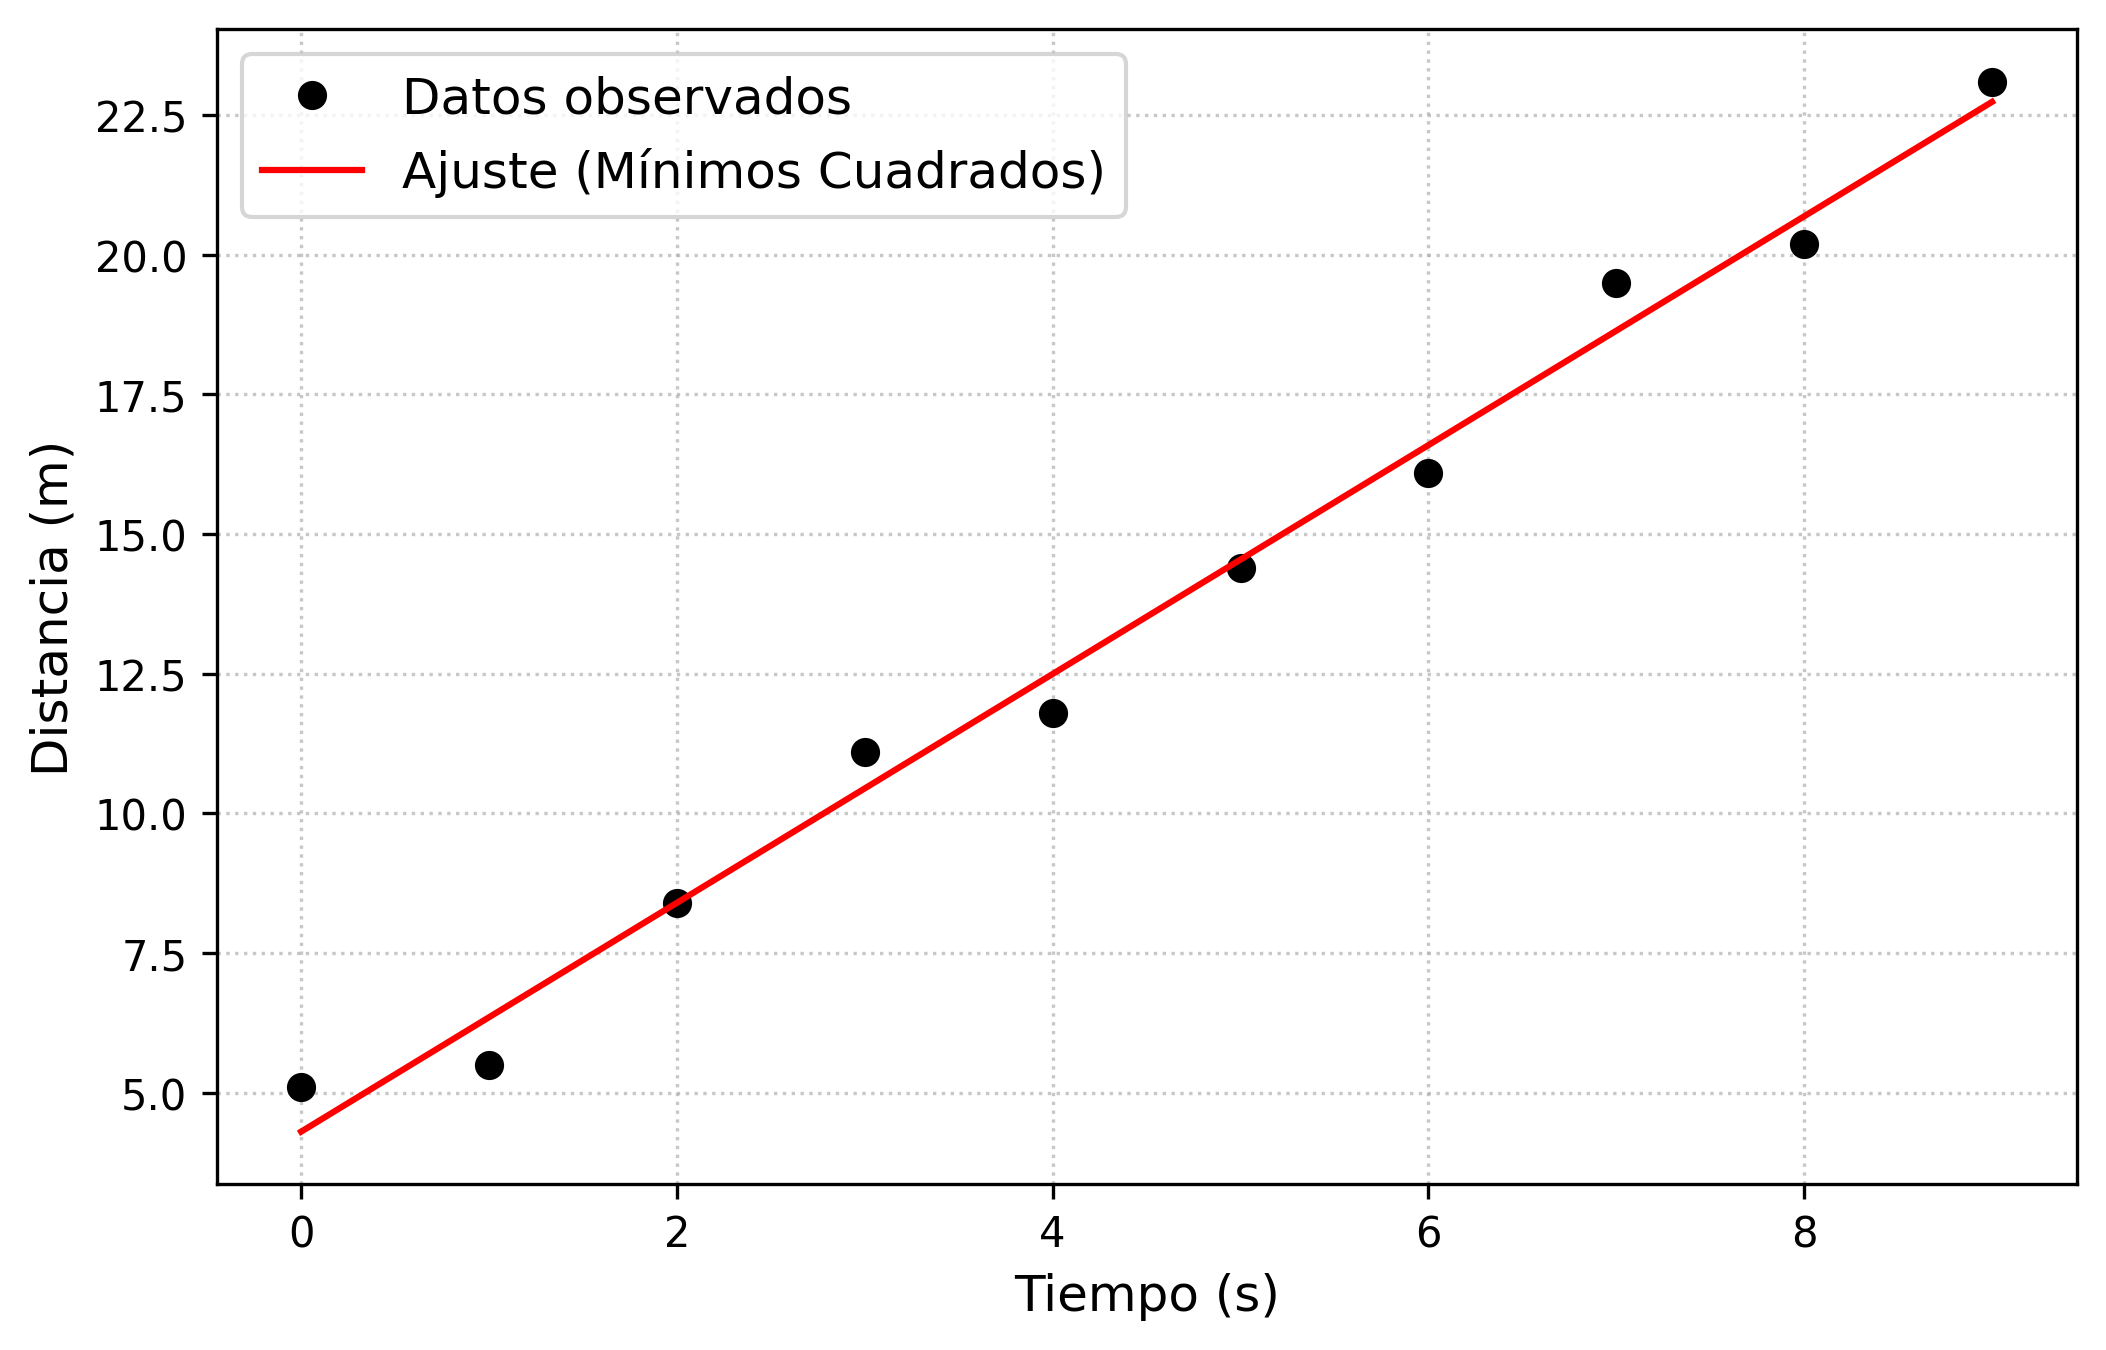

In [8]:
#Codigo aca!

tiempo = x     
distancia = y 

# Ajuste por mínimos cuadrados (polinomio de grado 1: lineal)
m, b = np.polyfit(tiempo, distancia, 1)

print(f"Ecuación óptima: d = {m:.3f}t + {b:.3f}")

# Evaluación de la recta para el gráfico
recta_ajuste = m * tiempo + b

# --- Visualización ---
plt.figure(figsize=(8, 5))
plt.plot(tiempo, distancia, 'o', label='Datos observados', color='black')
plt.plot(tiempo, recta_ajuste, '-', label=f'Ajuste (Mínimos Cuadrados)', color='red')

#plt.title('Ajuste Lineal: Distancia vs Tiempo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [9]:
#Calculamos la distancia en metros
t = 12
d = m * t + b
print(f"El valor de d cuanto t es 12 s, es: {d:.3f} (m)")
print(f"d_0 = {m:.3f}")
print(f"v = {b:.3f}")


El valor de d cuanto t es 12 s, es: 28.884 (m)
d_0 = 2.048
v = 4.302


**Cuáles son los valores de pendiente m e intercepto b encontrado? Con este modelo, cuánto es $d(t=12s)$?**

- **bestm**: 4.302 (m/s)
- **bestb**: 2.048 (m)
- **$d(t=12 s)$**: 28.884 (m)

In [10]:
bestm = m
bestb = b

Graficamos el mejor ajuste con los datos

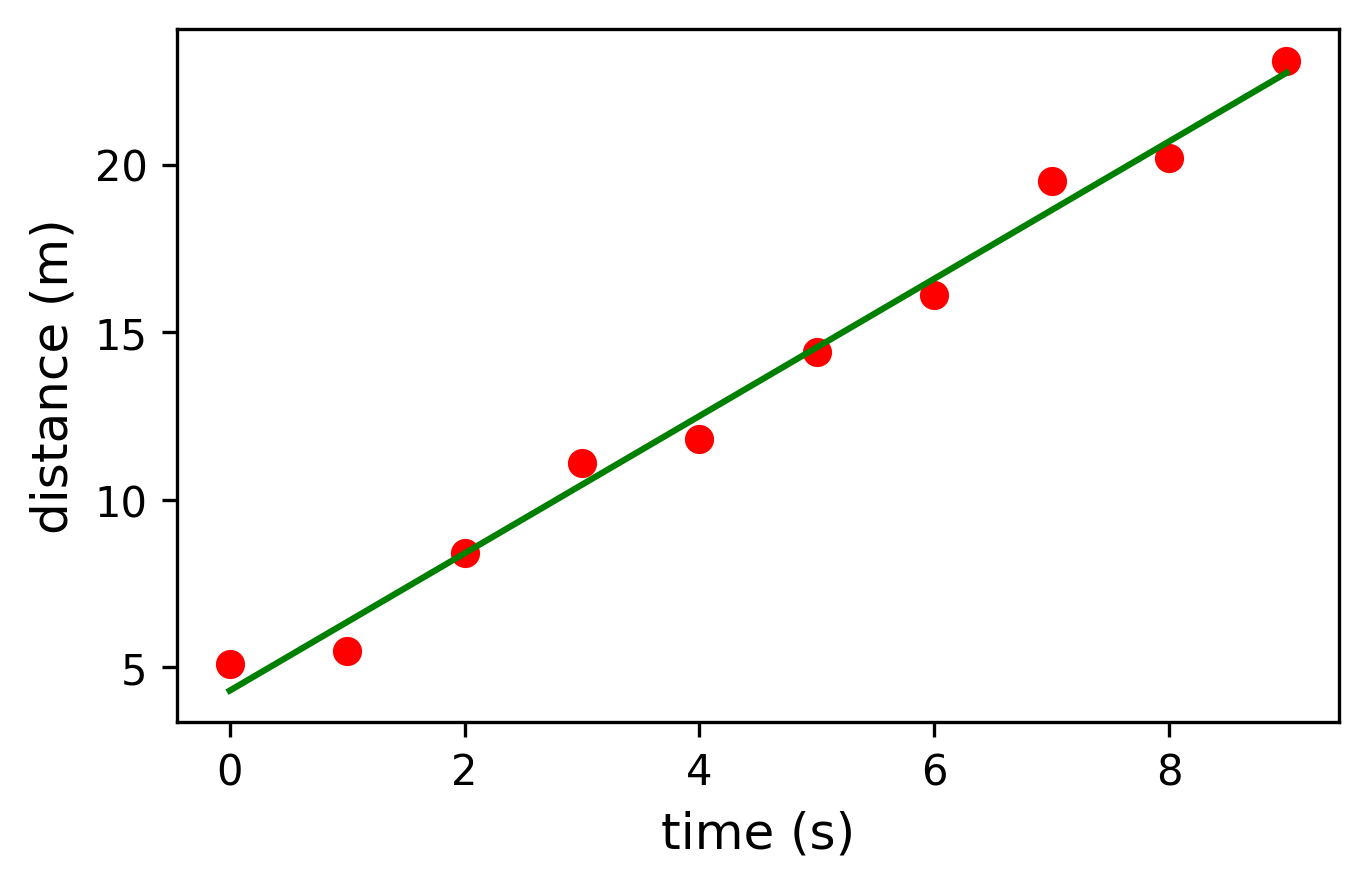

In [11]:
plt.figure(figsize=(5,3))
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestm*x+bestb, c = 'g'); #grafique la recta con los mejores parámetros

Y si agregamos incerteza en la medición de distancias?

In [12]:
np.random.seed(10)

dy = np.random.randn(10)*np.sqrt(2) #agregamos incertezas aleatorias, el signo no importa

In [13]:
dy

array([ 1.88314769,  1.01155723, -2.18552605, -0.01185655,  0.87870176,
       -1.01835477,  0.37549009,  0.1535108 ,  0.006069  , -0.24692199])

Text(0, 0.5, 'distance (m)')

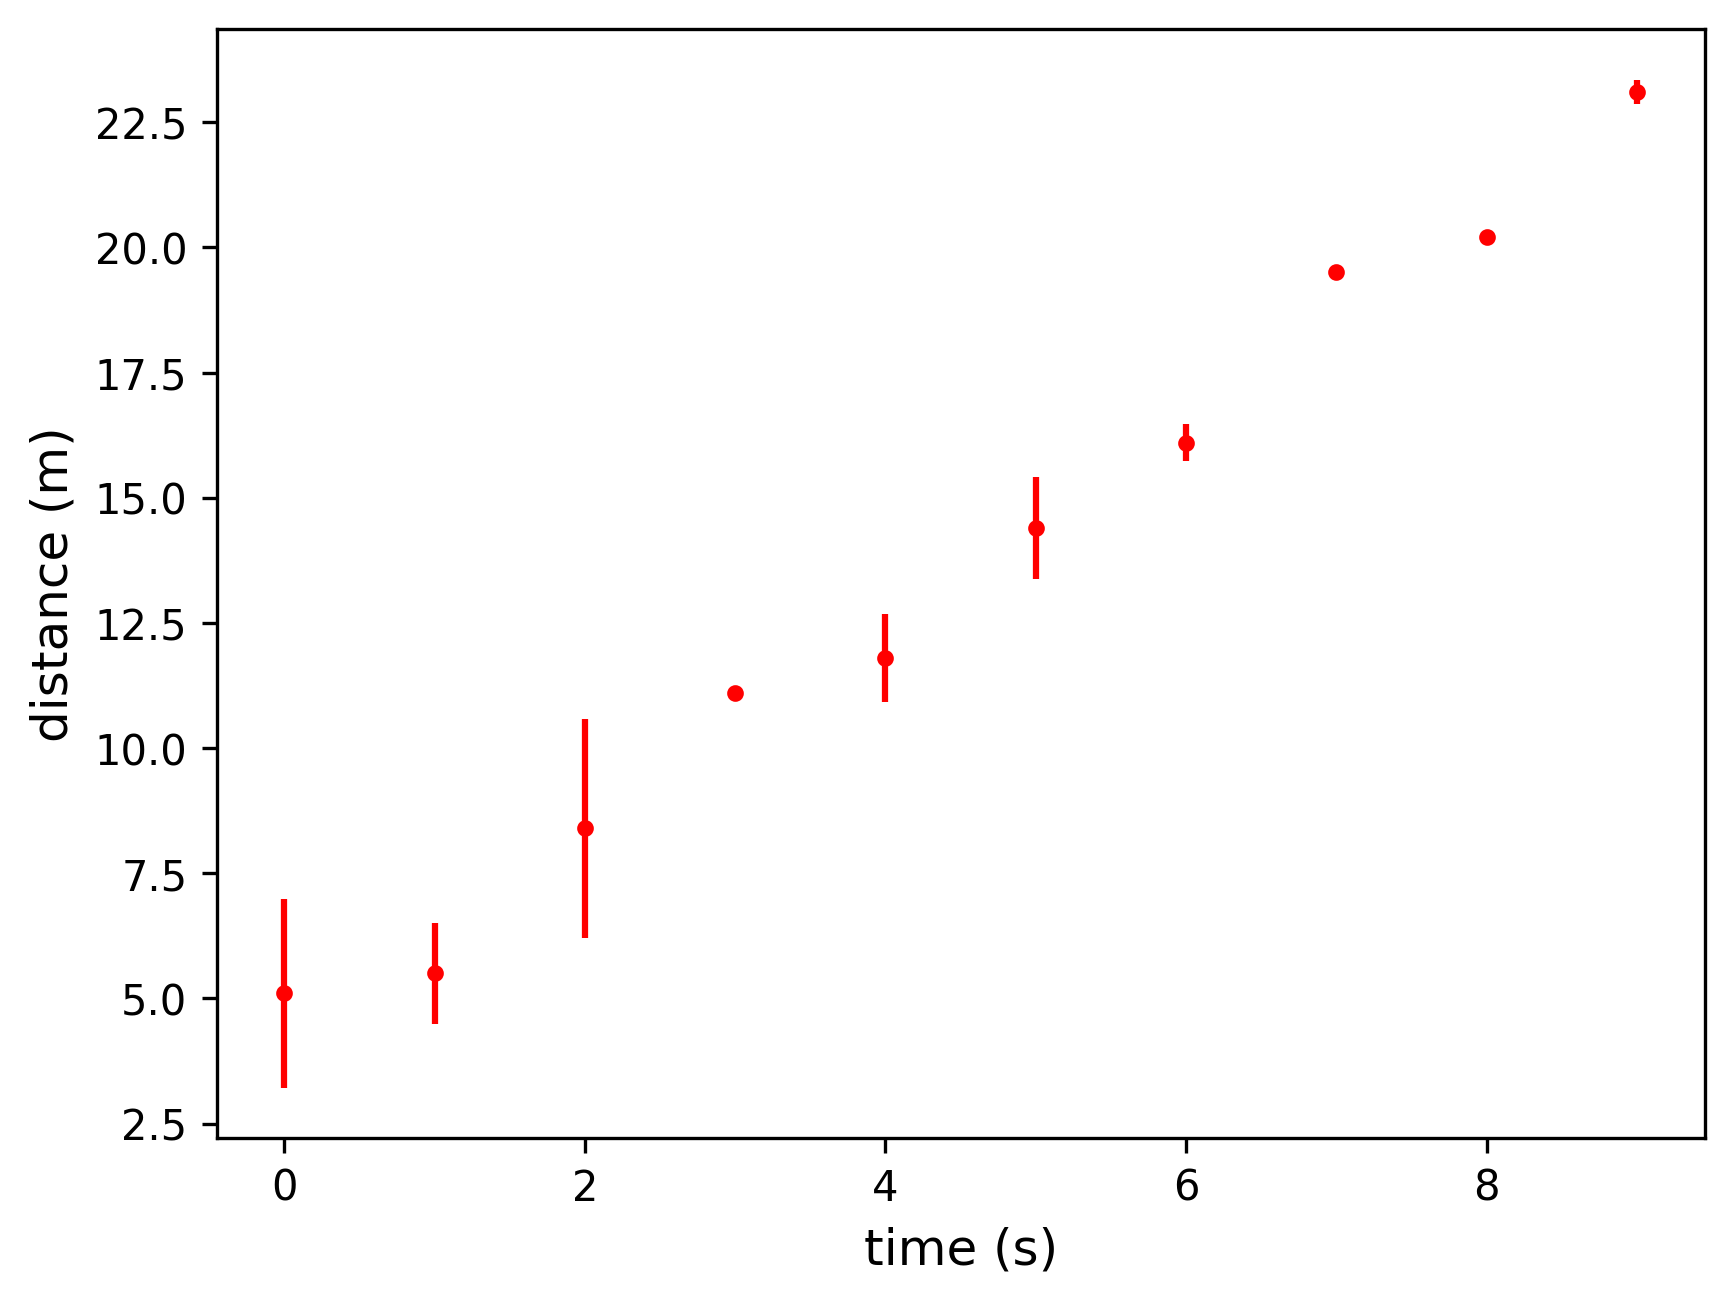

In [14]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

<details>
<summary>Ayuda!</summary>
    Cuando agregamos incertezas, debemos considerar que datos con menor incerteza tienen más "peso". Para esto, modificaremos la función de error cuadrado con el inverso de los cuadrados de las distancias. Esto se conoce como distribución $\chi^2$ (likelihood)


Encuentre los parámetros de la mejor recta cuando agregamos incertezas

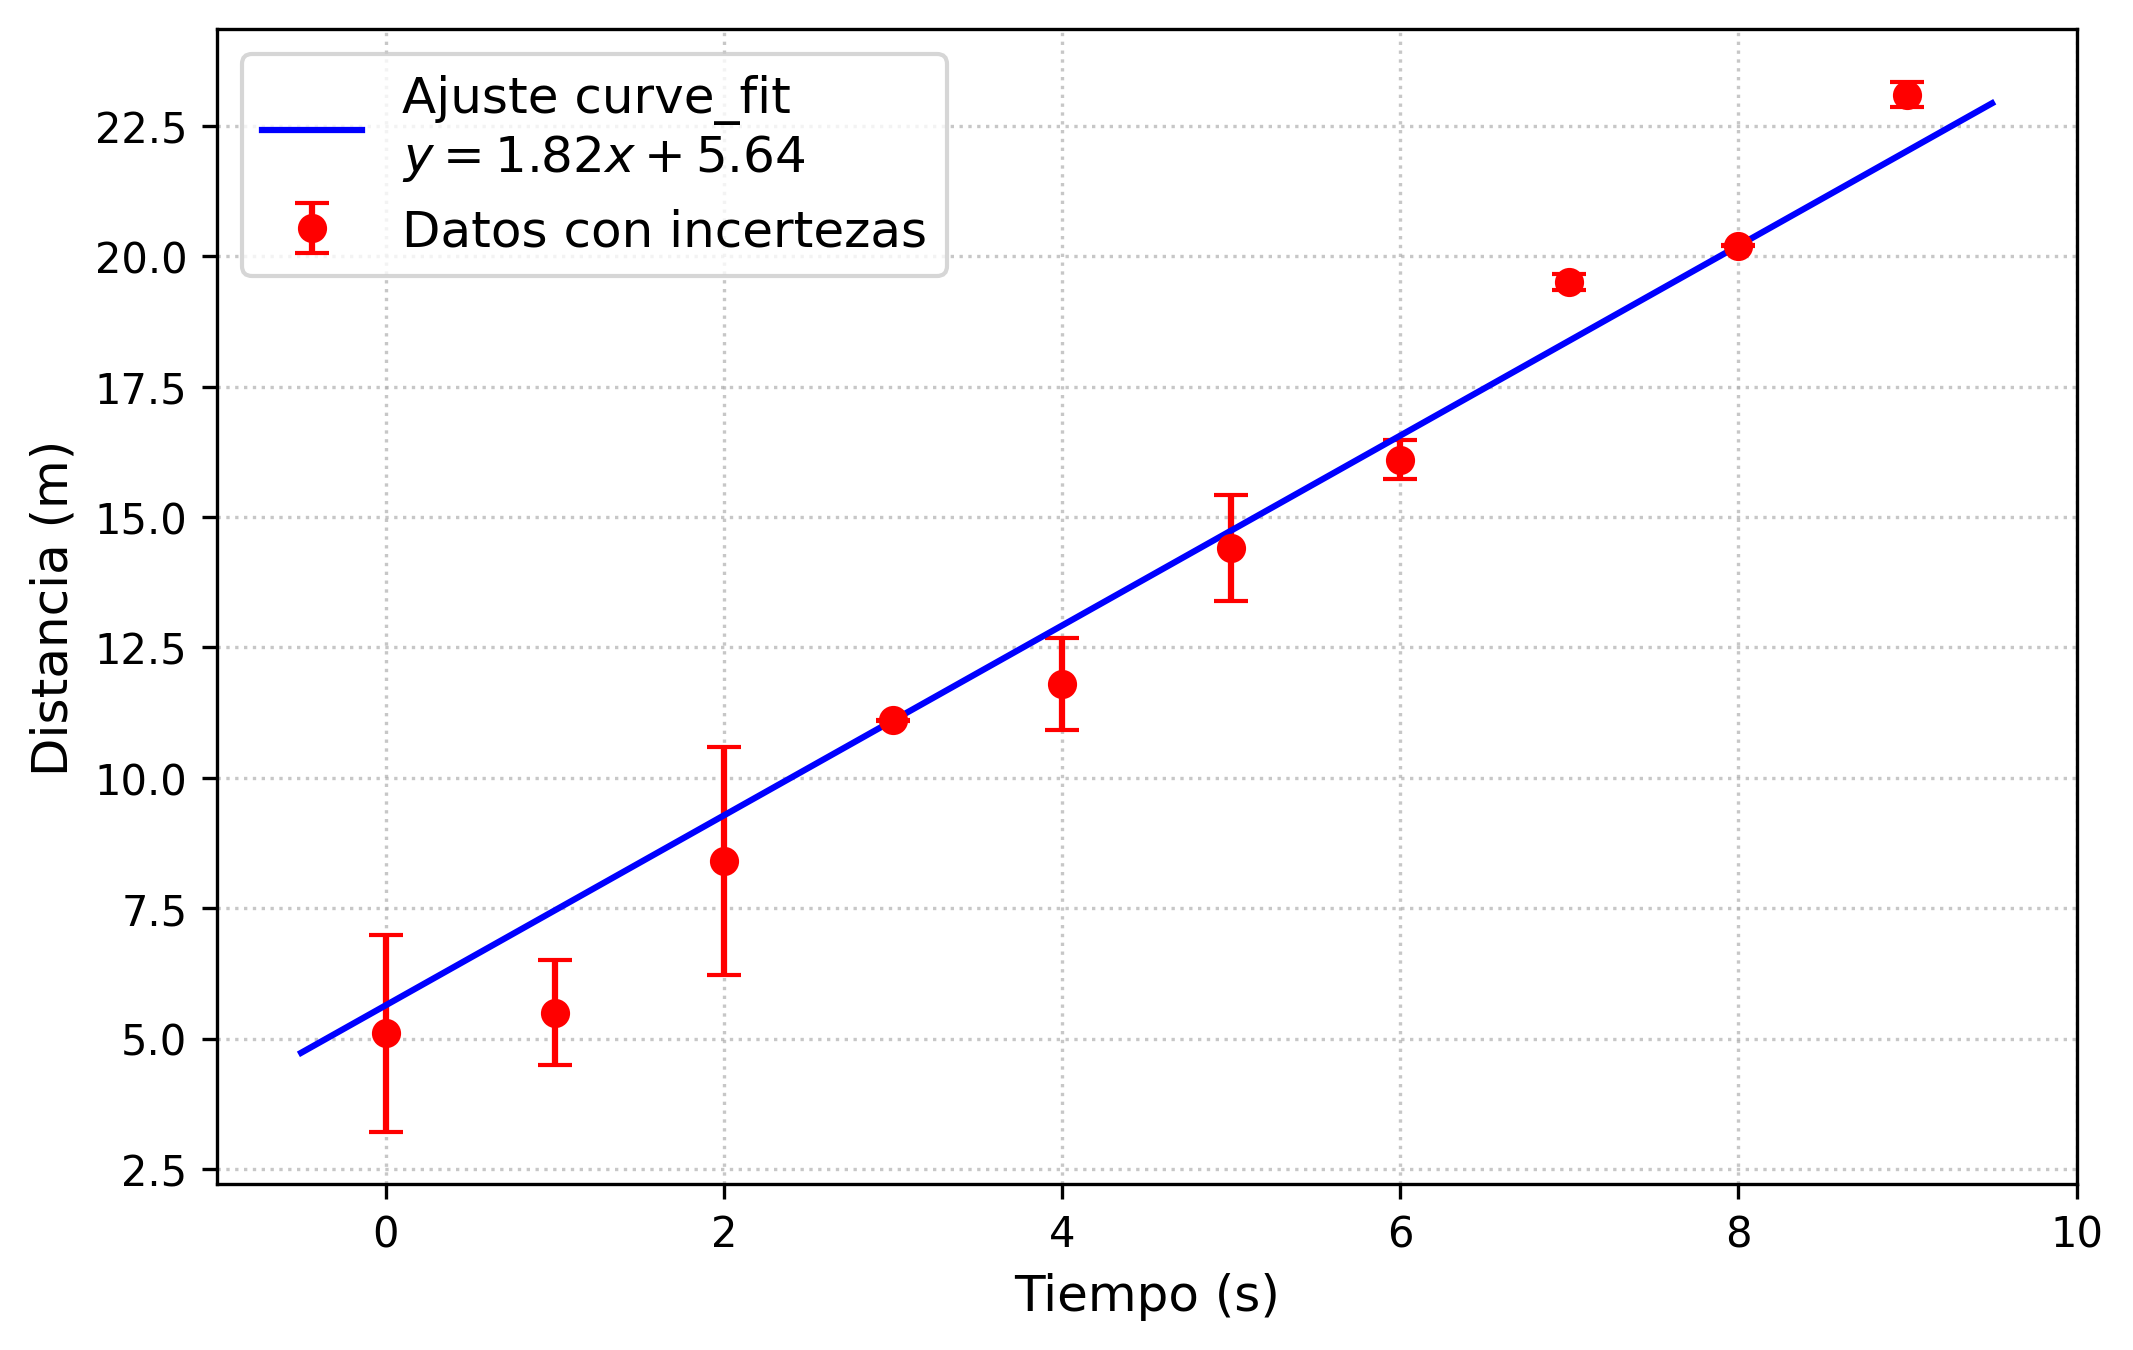

In [15]:
from scipy.optimize import curve_fit

# 1. Definimos la función de la recta
def recta(x, m, b):
    return m * x + b

# 2. Tus datos (reemplaza con los tuyos)
tiempo = x
distancia = y
errores_distancia = dy 

# --- Ajuste con curve_fit considerando las incertezas ---
# sigma recibe las incertezas
# absolute_sigma=True le dice que tus errores tienen las mismas unidades que la distancia
parametros_optimos, matriz_covarianza = curve_fit(
    recta, 
    tiempo, 
    distancia, 
    sigma=errores_distancia, 
    absolute_sigma=True
)

# Extraemos la pendiente y el intercepto
m_opt, b_opt = parametros_optimos

# Los errores de m y b están en la diagonal de la matriz de covarianza
errores_parametros = np.sqrt(np.diag(matriz_covarianza))
error_m, error_b = errores_parametros

# --- Visualización ---
plt.figure(figsize=(8, 5))

# Puntos con barras de error
plt.errorbar(tiempo, distancia, yerr=np.abs(errores_distancia), fmt='o', color='red', 
             label='Datos con incertezas', capsize=4)

# Recta de ajuste óptimo
t_linea = np.linspace(min(tiempo) - 0.5, max(tiempo) + 0.5, 100)
plt.plot(t_linea, recta(t_linea, m_opt, b_opt), '-', color='blue', 
         label=f'Ajuste curve_fit\n$y = {m_opt:.2f}x + {b_opt:.2f}$')

#plt.title('Mejor Ajuste Lineal usando curve_fit')
plt.xlabel('Tiempo (s)')
plt.ylabel('Distancia (m)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [16]:
# Mostramos los resultados formales
print("--- Resultados del Ajuste Ponderado ---")
print(f"Pendiente (m) : {m_opt:.3f} ± {error_m:.3f} (m/s)")
print(f"Intercepto (b): {b_opt:.3f} ± {error_b:.3f} (m)")

--- Resultados del Ajuste Ponderado ---
Pendiente (m) : 1.820 ± 0.003 (m/s)
Intercepto (b): 5.639 ± 0.019 (m)


Graficamos los datos con incertezas y el nuevo ajuste

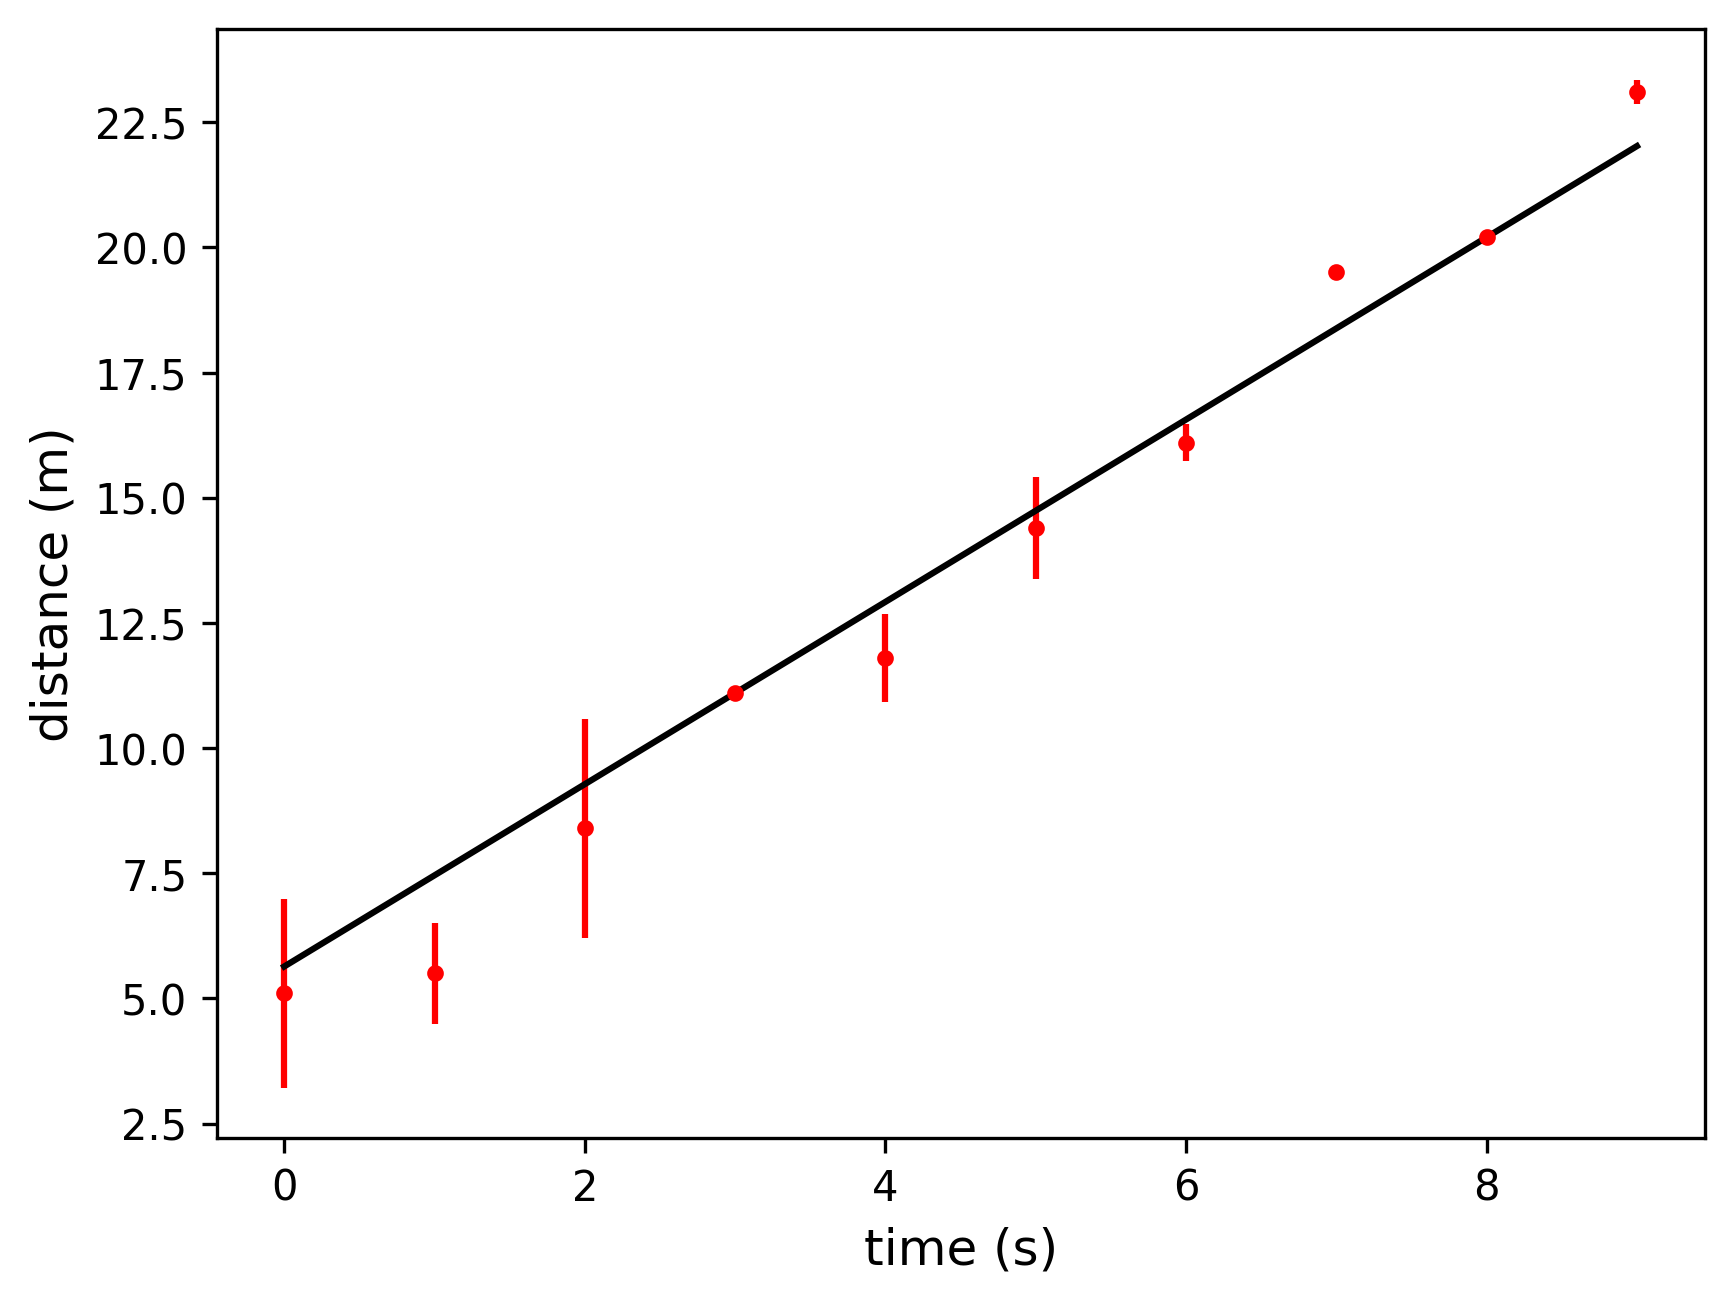

In [17]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, b_opt + m_opt * x, c = 'black') #agregue sus parámetros

Comparemos ambos modelos

<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:27: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_503507/1760218265.py:27: SyntaxWarning: invalid escape sequence '\c'
  print(f"Para tener una idea de la exactitud del modelo se usa $\chi^{2}$")


Para tener una idea de la exactitud del modelo se usa $\chi^2$
Chi-cuadrado total: 79.474
Chi-cuadrado reducido: 9.934


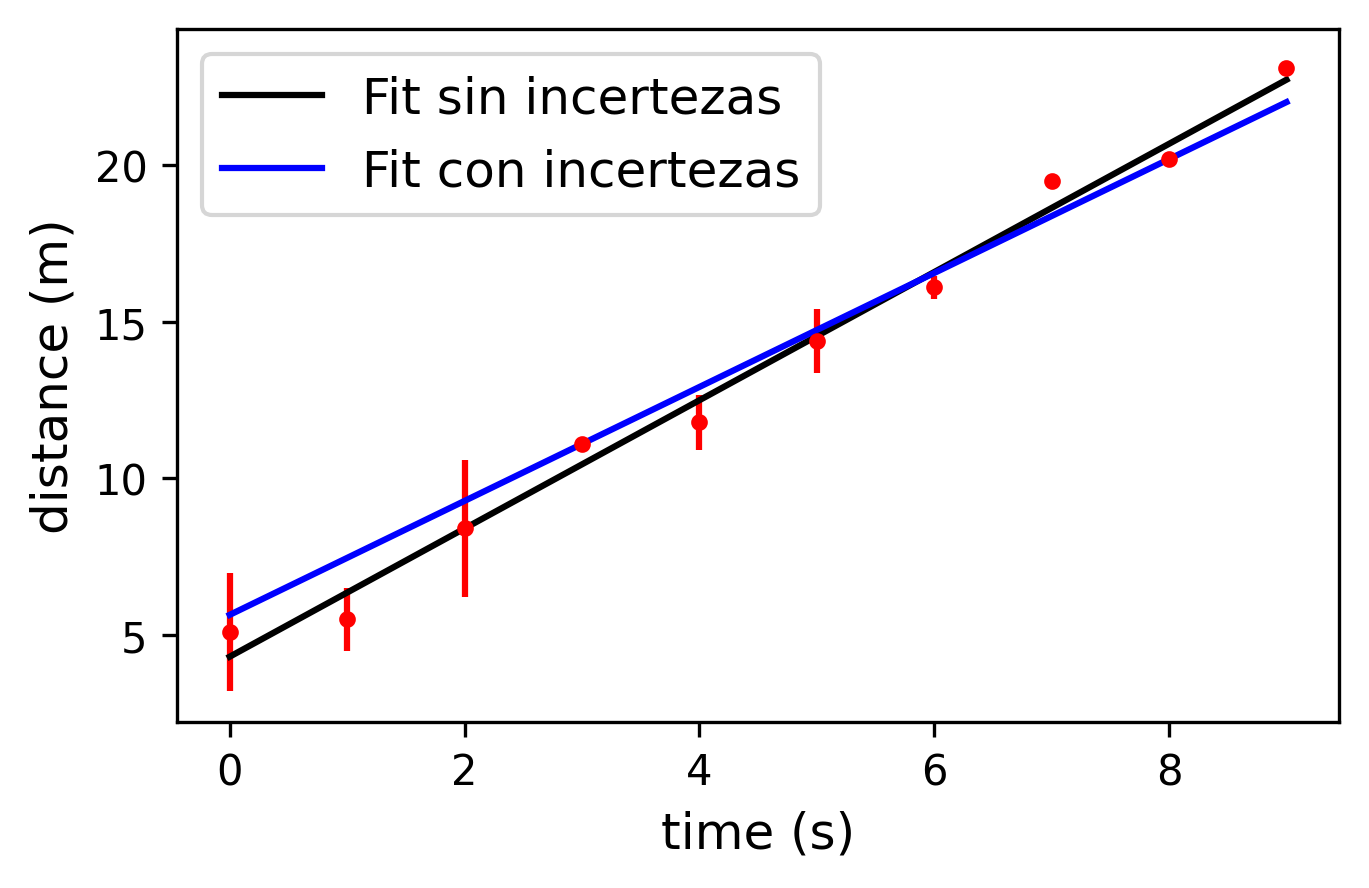

In [18]:
plt.figure(figsize=(5,3))

plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')

plt.plot(x, bestb + bestm * x, c = 'black', label = 'Fit sin incertezas')

plt.plot(x, b_opt + m_opt * x, c = 'b', label = 'Fit con incertezas')

plt.xlabel('time (s)')

plt.ylabel('distance (m)')

plt.legend()

# Calculamos los valores que predice tu recta para cada tiempo
distancia_modelo = m_opt * tiempo + b_opt

# Aplicamos la fórmula del Chi-cuadrado
# (Observado - Esperado) / Incerteza, todo eso al cuadrado y sumado
chi_cuadrado = np.sum(((distancia - distancia_modelo) / errores_distancia)**2)

# Calculamos el Chi-cuadrado reducido 
# Grados de libertad = Número de datos (N) - Número de parámetros ajustados (2)
grados_libertad = len(tiempo) - 2
chi_cuadrado_reducido = chi_cuadrado / grados_libertad

print(f"Para tener una idea de la exactitud del modelo se usa $\chi^{2}$")
print(f"Chi-cuadrado total: {chi_cuadrado:.3f}")
print(f"Chi-cuadrado reducido: {chi_cuadrado_reducido:.3f}")

**Pregunta: ¿Tiene sentido ese cambio?**

El cambio de pendiente tiene pleno sentido físico y estadístico. En el primer ajuste (recta negra), todos los puntos tienen el mismo peso, por lo que la recta intenta promediar la distancia a todos por igual. Sin embargo, al incorporar las incertezas (recta azul), el ajuste pasa a ser ponderado, donde el peso de cada dato es inversamente proporcional a su error ($w_i = 1/\sigma_i^2$). Al observar el gráfico, es evidente que la recta azul representa un modelo físicamente más robusto porque le da prioridad a las mediciones más exactas de nuestro experimento.

### Parte 2: Machine Learning

Si queremos resolver la pregunta de $d(t=12 s)=?$ usando aprendizaje de máquinas, la estrategia no es escribir explícitamente el modelo, ni los parámetros o el likelihood (aunque la elección de modelo sí afecta el resultado y la habilidad de aprender de los datos de entrenamiento).

En este caso, tenemos un problema de aprendizaje supervisado, donde nuestro set de datos inicial son los datos de aprendizaje. Debemos dividir estos datos en un conjunto de entrenamiento y prueba, de forma aleatoria (en el caso de una serie de tiempo esto no es verdad, pero en este caso no importa).

Consideraremos que nuestro problema es de regresión, porque la variable "target" es continua. Probaremos con dos modelos muy simples: Regresión lineal y Árbol de Decisión.

#### Importamos de la librería Sci-kit learn los modelos ya implementados y usaremos funciones de la librería para separar los datos en entrenamiento y prueba a partir de nuestros datos de distancia y tiempo creados al inicio del notebook

In [19]:
from sklearn.tree import DecisionTreeRegressor #modelo de árbol de decisión

In [20]:
from sklearn.linear_model import LinearRegression #modelo de regresión lineal

In [21]:
from sklearn.model_selection import train_test_split  #para dividir los datos

In [22]:
np.random.seed(10) #semilla fija para reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=3) #crea los sets de entrenamiento/prueba

In [23]:
X_train, y_train #7 datos de entrenamiento

(array([6, 3, 1, 0, 7, 4, 9]),
 array([16.1, 11.1,  5.5,  5.1, 19.5, 11.8, 23.1]))

In [24]:
X_test, y_test # 3 de prueba

(array([8, 2, 5]), array([20.2,  8.4, 14.4]))

In [25]:
treemodel = DecisionTreeRegressor() # Objeto "Estimator" de sklearn, con default params

In [26]:
regmodel = LinearRegression() # Objeto "Estimator" de sklearn, con default params default params

construimos el modelo con los datos de entrenamiento y los usamos para predecir el output en los datos de prueba

In [27]:
#predicciones de datos usando árbol de decisión
y_pred_tree = treemodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [28]:
#predicción usando regresión lineal
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [29]:
print(y_test, y_pred_reg, y_pred_tree) #Real/predicho por RL y AD respectivamente

[20.2  8.4 14.4] [20.89279279  8.41981982 14.65630631] [19.5  5.5 11.8]


Usaremos como métrica de evaluación los errores cuadrados promedio (MSE) para cada modelo

In [30]:
np.mean((y_test-y_pred_reg)**2)

np.float64(0.18201586721857252)

In [31]:
np.mean((y_test-y_pred_tree)**2)

np.float64(5.22)

**Pregunta: ¿Cuál modelo es mejor, RL o AD?**

El mejor modelo es el RL, ya que tiene el MSE más bajo, lo que nos dice explicitamente que el modelo que mejor predice los valores reales (o más se acerca a los valores reales), es el modelo de regresión lineal. Lo cual se debe principalmente a que RL puede extrapolar datos, mientras que el AD no puede e intenta predecir con el dato mas cercano.

Usamos el resultado para predecir $t = 12$ s con cada modelo

In [32]:
print(treemodel.predict(np.array(12).reshape(-1, 1)))
print(regmodel.predict(np.array(12).reshape(-1, 1)))

[23.1]
[29.20810811]


### Conclusión

Finalmente, cuál de las dos estrategias funcionó mejor, inferencia o ML?

- Hubiera funcionado la inferencia estadística si hubiéramos usando un modelo distinto (e.g sinusoidal)?
- En el caso de ML, cómo elegimos el mejor modelo?


**¿Cuál funciona mejor?**
- Mejor para Interpretabilidad: Si el objetivo es entender las relaciones entre variables y poder explicar esas relaciones de manera clara y comprensible, la inferencia estadística puede ser más adecuada. Esto es común en estudios científicos donde la interpretabilidad es clave.

- Mejor para Predicción: Si el objetivo es lograr la mejor precisión predictiva posible, especialmente con datos complejos y de gran escala, los métodos de aprendizaje automático tienden a ser más efectivos. Modelos como árboles de decisión, random forests, y redes neuronales suelen superar a los modelos estadísticos clásicos en tareas predictivas.

- Contexto del Problema: En problemas donde se necesita tanto interpretación como precisión, puede ser útil usar ambos enfoques. Por ejemplo, comenzar con modelos de inferencia para explorar los datos y entender las relaciones básicas, y luego usar ML para optimizar la precisión predictiva.

**¿Cuál estrategia funcionó mejor?:** En el caso especifico de extrapolar la distancia cuando $t=12 s$, la técnica de ML fue el más exitoso (preciso), más en especifico el modelo de Regresión Lineal, ya que presentó un MSE más bajo que el Árbol de decisiones (0.18 < 5.22). Entonces si de precisión hablamos las técnicas de ML son las indicadas para una cantidad adecuada de datos (en este caso 10 fue suficiente), en caso de tener una muestra muy pequeña, el modelo de ML no hubiera tenido buen rendimiento, ya que la maquina no hubiera tenido el mejor entrenamiento, para esta situación la inferencia sería la mejor herramienta. Por lo tanto, es buena idea usar ambas estrategias, debido a que se complementan bien y da una buena idea del problema en su completitud.

**¿Hubiera funcionado la inferencia estadística si hubiéramos usado un modelo distinto (e.g. sinusoidal)?** Definitivamente no. La inferencia estadística pierde toda su capacidad de interpretabilidad si la hipótesis de partida es físicamente incorrecta. Al observar los datos, existe una clara tendencia de crecimiento constante. Si hubiéramos forzado un modelo sinusoidal, el ajuste habría intentado doblar la curva sin sentido, entregando parámetros físicos absurdos y un error estadístico ($\chi^2$) colosal, muy superior al 9 obtenido.

**En el caso de ML, ¿cómo elegimos el mejor modelo?** El mejor modelo en Machine Learning se elige evaluando empíricamente su capacidad de generalización frente a datos que no conoce, midiendo su precisión predictiva a través de métricas de error. En esta actividad, la elección fue directa y numérica: la Regresión Lineal superó ampliamente al Árbol de Decisiones porque es capas de extrapolar los datos, permitiéndole lograr un MSE de 0.18, frente al MSE de 5.22 del modelo de árbol, el cual se sobreajustó al rango conocido y se estancó al intentar predecir el futuro.

**Conclusión general:** ML funcionó mejor para obtener el valor futuro con alta precisión (minimizando el MSE), pero la inferencia estadística funcionó mejor para diagnosticar la verdadera calidad y fiabilidad de los datos experimentales subyacentes, asi como una interpretación física del fenómeno en estudio.